# Flagging Vendor Invoices for Manual Review

## Objective

Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

## Business Importance

- Manual invoice review is time-consuming and does not scale with transaction volume.
- Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
- An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
db_path = r'C:\Users\anike\Downloads\inventory.db'
conn = sqlite3.connect(db_path)

In [3]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
for table in tables['name']:
  print('Table name:',table)
  df=pd.read_sql_query(f"select * from {table} limit 5",conn)
  display(df)

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [5]:
purchase_agg_df= pd.read_sql_query("""select PONumber,
count(distinct Brand) as total_brands,
sum(Quantity) as total_item_quantity,
sum(Dollars) as total_item_dollars,
avg(julianday(ReceivingDate) - julianday(PODate)) as avg_receiving_delay
from purchases
group by PONumber""",conn)

In [6]:
invoice_agg_df= pd.read_sql_query("""select PONumber,
Quantity as invoice_quantity,
Dollars as invoice_dollars,
Freight,
(julianday(InvoiceDate) - julianday(PODate)) as days_po_to_invoice,
(julianday(PayDate) - julianday(InvoiceDate)) as days_to_pay
from vendor_invoice""",conn)

In [7]:
df=purchase_agg_df.merge(invoice_agg_df,on="PONumber",how="left")
df

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8106,81,10100,137483.78,12.614130,10100,137483.78,2935.20,23.0,24.0
1,8107,2,24,348.72,12.500000,24,348.72,9.08,16.0,36.0
2,8108,165,8466,60281.13,12.632479,8466,60281.13,1549.81,22.0,30.0
3,8109,23,2246,14298.09,12.626866,2246,14298.09,408.72,23.0,30.0
4,8110,183,8086,56493.23,12.695271,8086,56493.23,1300.92,20.0,41.0
...,...,...,...,...,...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968,65,1248.61,5.74,17.0,41.0
5539,13658,111,14115,102949.38,5.016349,38896,502128.05,2761.70,18.0,40.0
5540,13659,13,338,2492.20,4.735294,195,2599.66,11.70,12.0,37.0
5541,13660,12,195,2599.66,4.611111,60,694.68,3.20,15.0,43.0


In [8]:
df.isnull().sum()

PONumber               0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
dtype: int64

In [9]:
df.dtypes

PONumber                 int64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
dtype: object

In [36]:
def create_invoice_risk_label(row):
    # Invoice total mismatch with item-level total
    if abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5:
        return 1

    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1

    return 0
df["flag_invoice"] = df.apply(
    create_invoice_risk_label,
    axis=1
)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64


In [11]:
df.corr()

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,flag_invoice
PONumber,1.000000,0.013423,0.049442,0.059221,-0.042362,0.049230,0.058917,0.043617,-0.002234,0.012558,0.564946
total_brands,0.013423,1.000000,0.783825,0.753092,0.000496,0.566394,0.536952,0.536381,0.009519,0.020336,0.008961
total_item_quantity,0.049442,0.783825,1.000000,0.963831,-0.014016,0.706117,0.667666,0.656616,0.005543,0.016203,0.032783
total_item_dollars,0.059221,0.753092,0.963831,1.000000,-0.014251,0.668171,0.679537,0.670768,0.007931,0.015610,0.037994
avg_receiving_delay,-0.042362,0.000496,-0.014016,-0.014251,1.000000,0.000519,0.004694,0.015645,0.515538,-0.029403,0.311667
invoice_quantity,0.049230,0.566394,0.706117,0.668171,0.000519,1.000000,0.963831,0.946550,0.000526,0.022284,0.032783
invoice_dollars,0.058917,0.536952,0.667666,0.679537,0.004694,0.963831,1.000000,0.985141,0.001610,0.025661,0.037994
Freight,0.043617,0.536381,0.656616,0.670768,0.015645,0.946550,0.985141,1.000000,0.003265,0.025513,0.037759
days_po_to_invoice,-0.002234,0.009519,0.005543,0.007931,0.515538,0.000526,0.001610,0.003265,1.000000,-0.370432,0.183115
days_to_pay,0.012558,0.020336,0.016203,0.015610,-0.029403,0.022284,0.025661,0.025513,-0.370432,1.000000,-0.005289


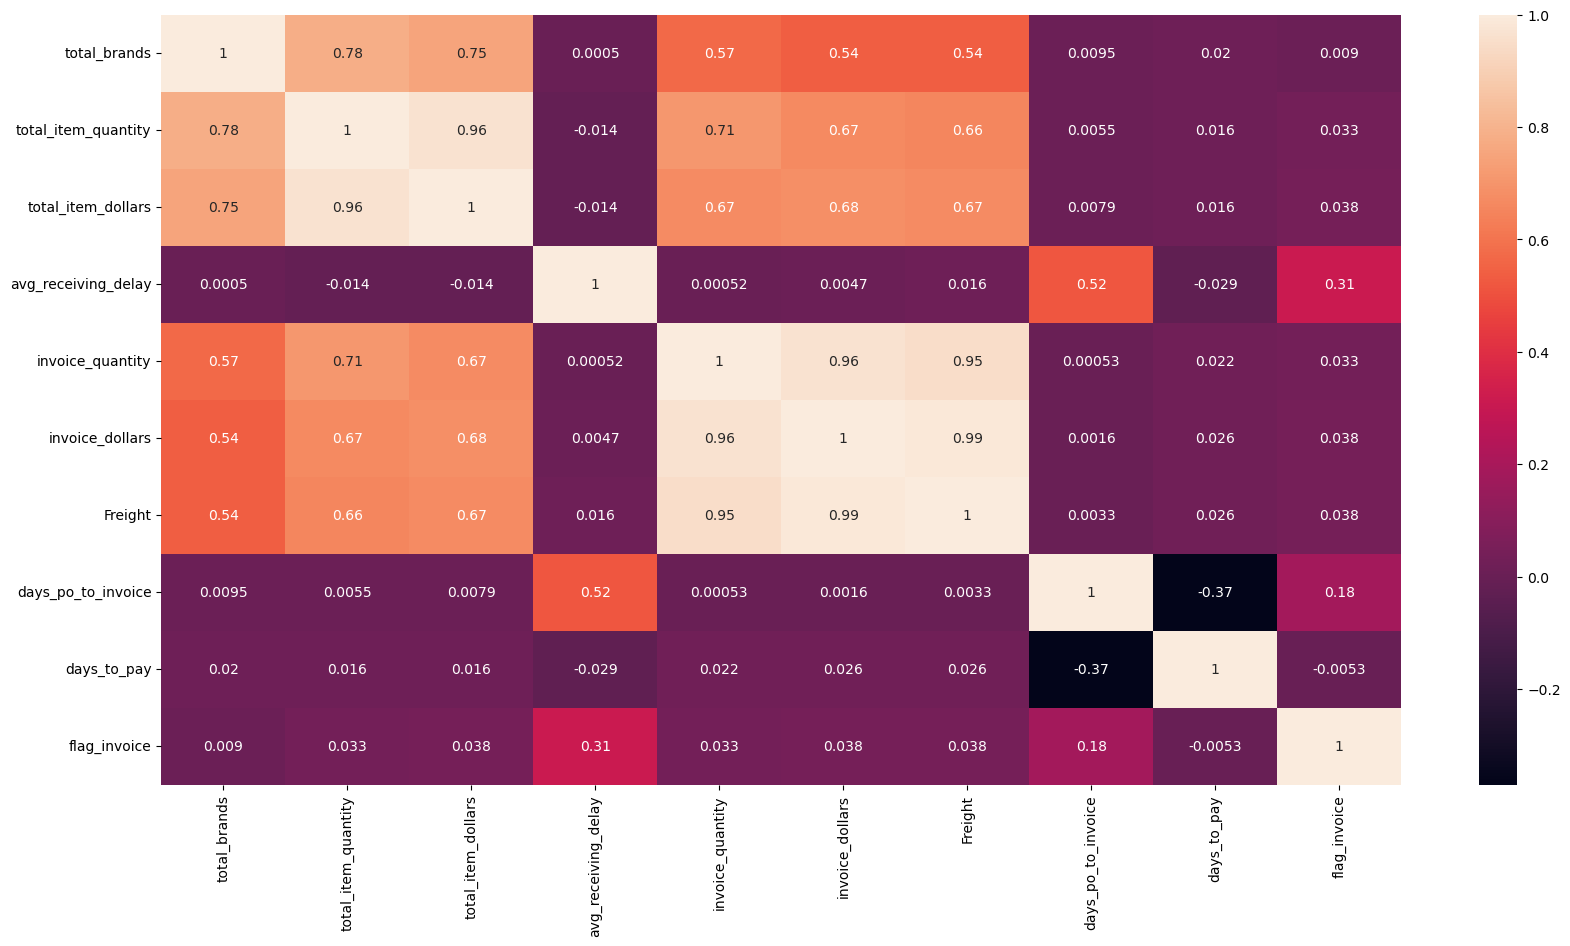

In [12]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr().iloc[1:,1:],annot=True)
plt.show()

In [13]:
flagged=df[df["flag_invoice"]==1]
normal=df[df["flag_invoice"]==0] 

In [14]:
significant_features=[]
non_significant_features=[]
results=[]

metrics = [
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'days_po_to_invoice',
    'days_to_pay',
    'total_brands',
    'total_item_quantity',
    'total_item_dollars',
    'avg_receiving_delay'
]

In [15]:
from scipy.stats import ttest_ind
for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()
    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )
    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": round(flagged_mean, 2),
            "normal_mean": round(normal_mean, 2),
            "p_value": round(p_value, 3)
        })
    else:
        non_significant_features.append(metric)

In [16]:
non_significant_features

['days_to_pay', 'total_brands']

In [17]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [18]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)}]

In [19]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_brands', 'total_item_quantity', 'days_po_to_invoice', 'total_item_dollars']]
Y = df['flag_invoice']

In [20]:
X.describe()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.000000,5.543000e+03,5543.000000,5543.000000,5543.000000,5543.000000,5.543000e+03
mean,6058.880931,5.807338e+04,295.954301,41.312466,6058.880931,16.424499,5.807338e+04
std,14453.338164,1.402340e+05,713.585093,76.940674,14453.338164,3.127282,1.402340e+05
min,1.000000,4.140000e+00,0.020000,1.000000,1.000000,9.000000,4.140000e+00
25%,83.000000,9.678100e+02,5.020000,3.000000,83.000000,14.000000,9.678100e+02
50%,423.000000,4.765450e+03,24.730000,7.000000,423.000000,16.000000,4.765450e+03
75%,5100.500000,4.458718e+04,229.660000,46.000000,5100.500000,19.000000,4.458718e+04
max,141660.000000,1.660436e+06,8468.220000,807.000000,141660.000000,23.000000,1.660436e+06


In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.8,random_state=42)

In [22]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler =StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, Y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, Y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_test, Y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(Y_test, y_pred)

    print(f"\n{model_name} Performance:")
    print(f"Accuracy : {accuracy:.2f}")

    print("Classification Report :")
    print(classification_report(Y_test, y_pred))
    return {
        "model_name": model_name,
        "accuracy": accuracy
    }

evaluate_model(model1, X_test, Y_test, 'Logistic Regression')
evaluate_model(model2, X_test, Y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test, Y_test, 'Random Forest Classifier')

In [25]:
model3.feature_importances_

array([0.13930544, 0.14987799, 0.1347569 , 0.08901877, 0.18463444,
       0.07207655, 0.23032991])

In [26]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
6,total_item_dollars,0.230330
4,total_item_quantity,0.184634
1,invoice_dollars,0.149878
0,invoice_quantity,0.139305
2,Freight,0.134757
3,total_brands,0.089019
5,days_po_to_invoice,0.072077


In [27]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_item_quantity', 'total_item_dollars']]
Y = df['flag_invoice']

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.8,random_state=42)

scaler =StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, Y_train)

evaluate_model(model3, X_test, Y_test, 'Random Forest Classifier')


Random Forest Classifier Performance:
Accuracy : 0.56
Classification Report :
              precision    recall  f1-score   support

           0       0.65      0.71      0.68       716
           1       0.36      0.29      0.32       393

    accuracy                           0.56      1109
   macro avg       0.50      0.50      0.50      1109
weighted avg       0.54      0.56      0.55      1109



{'model_name': 'Random Forest Classifier', 'accuracy': 0.5617673579801623}

In [29]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
 }

In [30]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)
scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)
grid_search.fit(X_train_scaled, Y_train)

evaluate_model(
    grid_search,
    X_test_scaled,
    Y_test,
    "Random Forest Classifier"
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classifier Performance:
Accuracy : 0.88
Classification Report :
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       716
           1       0.96      0.69      0.80       393

    accuracy                           0.88      1109
   macro avg       0.91      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109



{'model_name': 'Random Forest Classifier', 'accuracy': 0.8809738503155996}

In [31]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest F1 Score (Cross Validation):")
print(grid_search.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}

Best F1 Score (Cross Validation):
0.8014695747397671


In [32]:
from sklearn.metrics import confusion_matrix

In [33]:
cf1= confusion_matrix(grid_search.predict(X_test_scaled),Y_test)

In [37]:
cf1


array([[705, 121],
       [ 11, 272]])

In [34]:
cf2= confusion_matrix(model3.predict(X_test_scaled),Y_test)

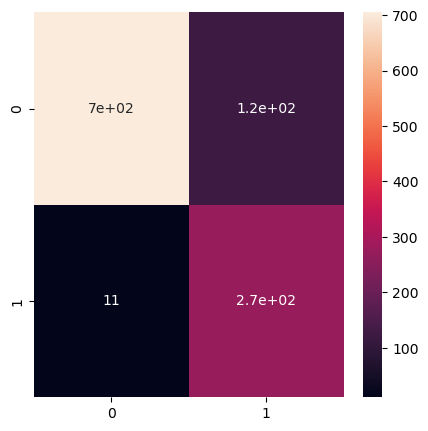

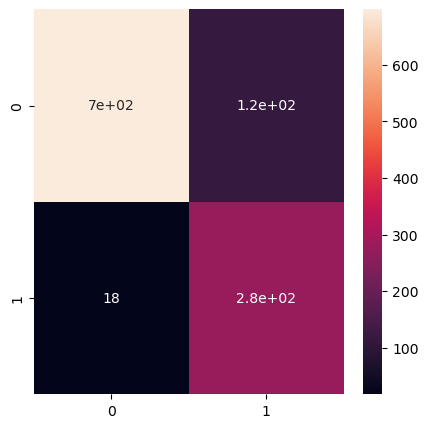

In [35]:
plt.figure(figsize=(5,5))
sns.heatmap(cf1,annot=True)
plt.show()

plt.figure(figsize=(5,5))
sns.heatmap(cf2,annot=True)
plt.show()